# Análisis de Clustering: K-Means y Clustering Jerárquico

In [93]:
import pandas as pd # Manejo y análisis de estructuras de datos
import numpy as np # Cálculo numérico y el análisis de datos
import seaborn as sns # Creación gráficos estadísticos
import matplotlib.pyplot as plt # Creación de gráficos en dos dimensiones
import plotly.graph_objs as go # Creación de gráficos en tres dimensiones
import plotly.express as px # Creación de gráficos en tres dimensiones

# librerías de para implementar modelo Kmeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
# librerías de para evaluar el modelo
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
#Librería para evitar la advertencia de que el modelo de KMeans tiene una pérdida de memoria en Windows 
import warnings
warnings.filterwarnings('ignore')





In [97]:
# Cargar dataset
df = pd.read_csv("C:/Kmeans/Mall_Customers.csv")


In [99]:
#Lectura de datos
df.head(40)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [101]:
# Codificar y escalar
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Eliminar CustomerID
df = df.drop('CustomerID', axis=1)

# Escalar datos
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [25]:
#Lectura de datos
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [26]:
# Descripción de los datos
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [27]:
#Revisión del tipo de datos y datos faltantes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

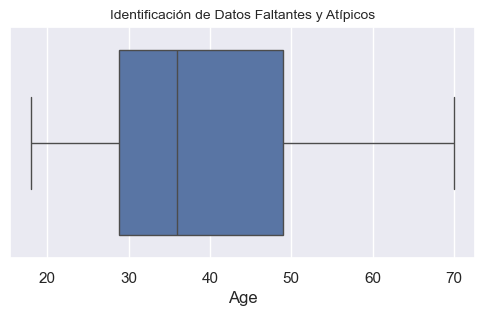

In [28]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Age'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0, 0.5, 'Count')

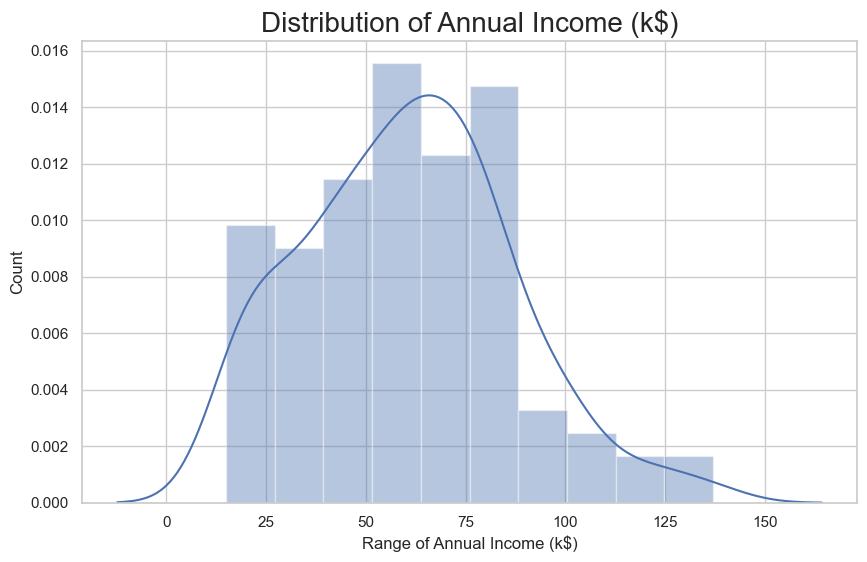

In [29]:
#Distribution of Annnual Income
plt.figure(figsize=(10, 6))
sns.set(style = 'whitegrid')
sns.distplot(df['Annual Income (k$)'])
plt.title('Distribution of Annual Income (k$)', fontsize = 20)
plt.xlabel('Range of Annual Income (k$)')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

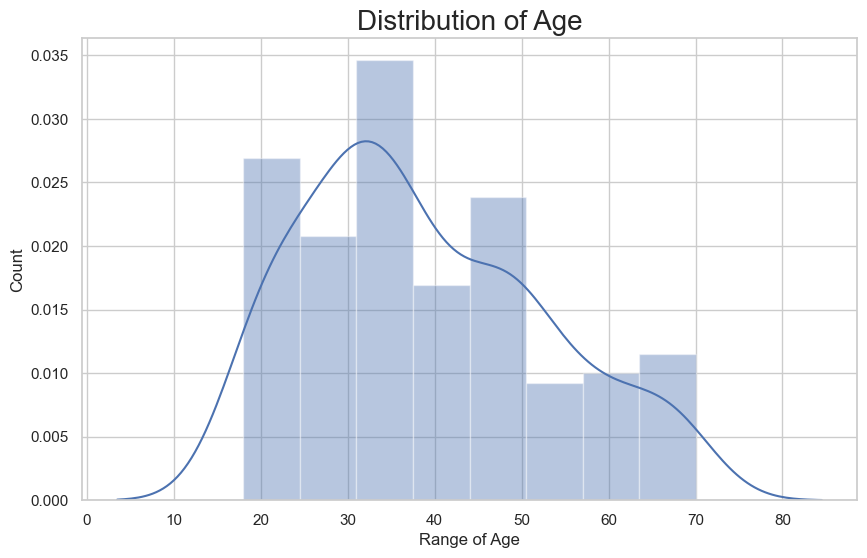

In [30]:
#Distribution of age
plt.figure(figsize=(10, 6))
sns.set(style = 'whitegrid')
sns.distplot(df['Age'])
plt.title('Distribution of Age', fontsize = 20)
plt.xlabel('Range of Age')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

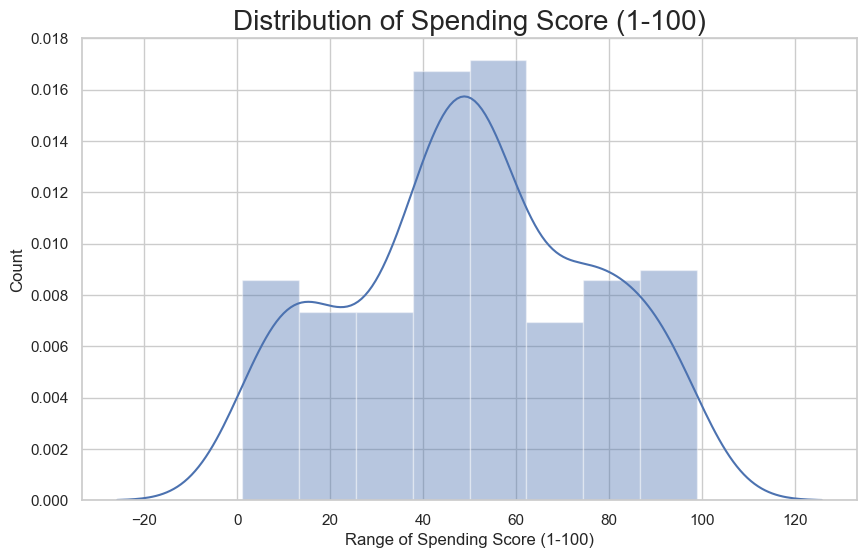

In [31]:
#Distribution of spending score
plt.figure(figsize=(10, 6))
sns.set(style = 'whitegrid')
sns.distplot(df['Spending Score (1-100)'])
plt.title('Distribution of Spending Score (1-100)', fontsize = 20)
plt.xlabel('Range of Spending Score (1-100)')
plt.ylabel('Count')

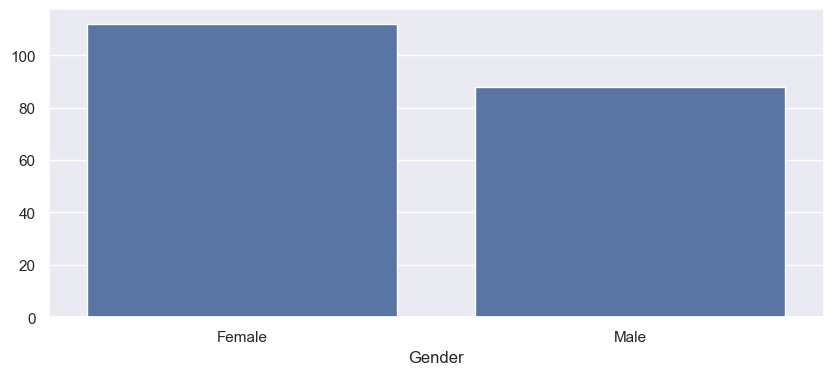

In [32]:
#Analisis por Género
genders = df.Gender.value_counts()
sns.set_style("darkgrid")
plt.figure(figsize=(10,4))
sns.barplot(x=genders.index, y=genders.values)
plt.show()

In [33]:
#We take just the Annual Income and Spending score
df1=df[["CustomerID","Gender","Age","Annual Income (k$)","Spending Score (1-100)"]]
X=df1[["Annual Income (k$)","Spending Score (1-100)"]]

In [34]:
#The input data
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


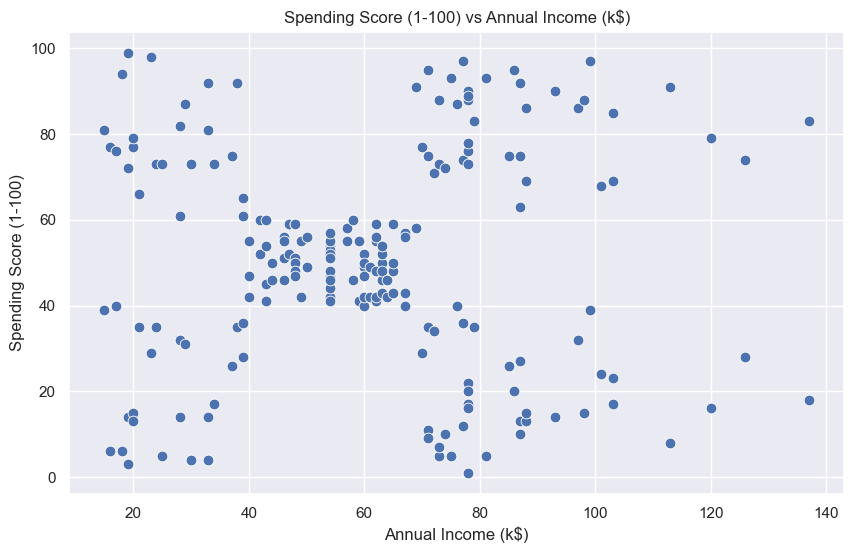

In [35]:
# Grafica antes del agrupamiento
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',  data = X  ,s = 60 )
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)') 
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.show()

In [36]:
#Seleccionando 5 clusters
km1=KMeans(n_clusters=5)
#Fitting the input data
km1.fit(X)
#predicting the labels of the input data
y=km1.predict(X)
#adding the labels to a column named label
df["label"] = y
#The new dataframe with the clustering done
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),label
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


In [37]:
#Importing KMeans from sklearn
from sklearn.cluster import KMeans

In [73]:
wcss=[]
for i in range(1,15):
    km=KMeans(n_clusters=i)
    km.fit(X)
    wcss.append(km.inertia_)

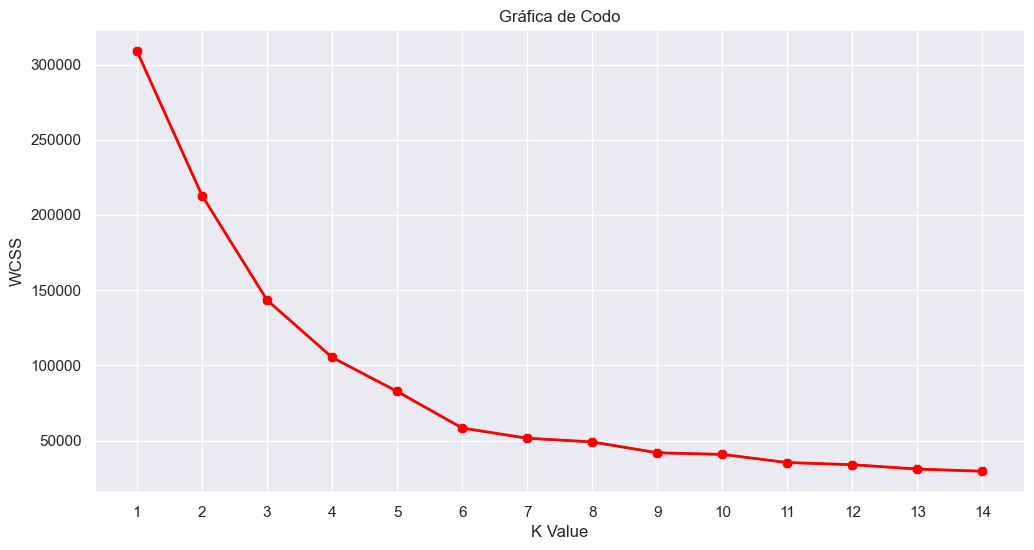

In [75]:
#Gráfico de Codo
plt.figure(figsize=(12,6))
plt.plot(range(1,15),wcss)
plt.plot(range(1,15),wcss, linewidth=2, color="red", marker ="8")
plt.xlabel("K Value")
plt.xticks(np.arange(1,15,1))
plt.ylabel("WCSS")
plt.title('Gráfica de Codo')
plt.show()

In [40]:
# Filtrar columnas del modelo 

df = df[["Age","Annual Income (k$)","Spending Score (1-100)"]]

In [41]:
# Revisión de los datos de las variables objetivo

df.head(10)

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
5,22,17,76
6,35,18,6
7,23,18,94
8,64,19,3
9,30,19,72


In [53]:
#4. Entrenar el modelo configurando los diferentes hiperparámetros
# Generación del modelo de Agrupamiento del modelo con K=5 (Es decir haremos 5 grupos de agrupamiento) 

Modelo = KMeans(n_clusters=5, random_state=0)
Modelo.fit(df)
 

KMeans(n_clusters=5, random_state=0)

In [55]:
#Se agrega la columna Grupo a la BD para identificar el numero de grupo del agrupamiento

Modelo.labels_
df["Grupo"] = Modelo.labels_ 
print (df)

     Age  Annual Income (k$)  Spending Score (1-100)  Grupo
0     19                  15                      39      2
1     21                  15                      81      2
2     20                  16                       6      0
3     23                  16                      77      2
4     31                  17                      40      0
..   ...                 ...                     ...    ...
195   35                 120                      79      1
196   45                 126                      28      3
197   32                 126                      74      1
198   32                 137                      18      3
199   30                 137                      83      1

[200 rows x 4 columns]


In [ ]:
#5. Evaluar el desempeño del modelo con métricas como Coeficiente de Silhouette, Índice de Calinski-Harabasz, etc


In [59]:
# Desempeño del modelo con el Coeficiente de Silhouette el Índice de Calinski-Harabasz y el índice de Davies Bouldin Score

# Preparación de la metrica de la columna Grupo
Observaciones = len(df)
X = df.drop('Grupo', axis=1)
clusters = df['Grupo']

# Se calculan las métricas
sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)
davies_score = davies_bouldin_score(X, clusters)

# Se crea una tabla para mostrar los valores de las métricas
table_data = [
    ["Numero de Observaciones", Observaciones],
    ["Coeficiente Silhouette", sil_score],
    ["Indice Calinski Harabasz", calinski_score],
    ["Indice Davies Bouldin", davies_score]
]

# Imprime la tabla
from tabulate import tabulate
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='pretty'))

+--------------------------+--------------------+
|          Metric          |       Value        |
+--------------------------+--------------------+
| Numero de Observaciones  |        200         |
|  Coeficiente Silhouette  | 0.3771108731967625 |
| Indice Calinski Harabasz | 133.49030043802063 |
|  Indice Davies Bouldin   | 0.9845471043038023 |
+--------------------------+--------------------+


In [ ]:
#6. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo


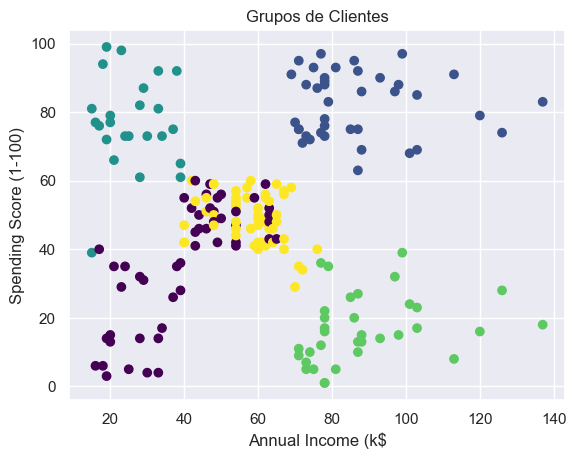

In [63]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Grupo'], cmap='viridis')
plt.xlabel('Annual Income (k$')
plt.ylabel('Spending Score (1-100)')
plt.title('Grupos de Clientes')
plt.show()

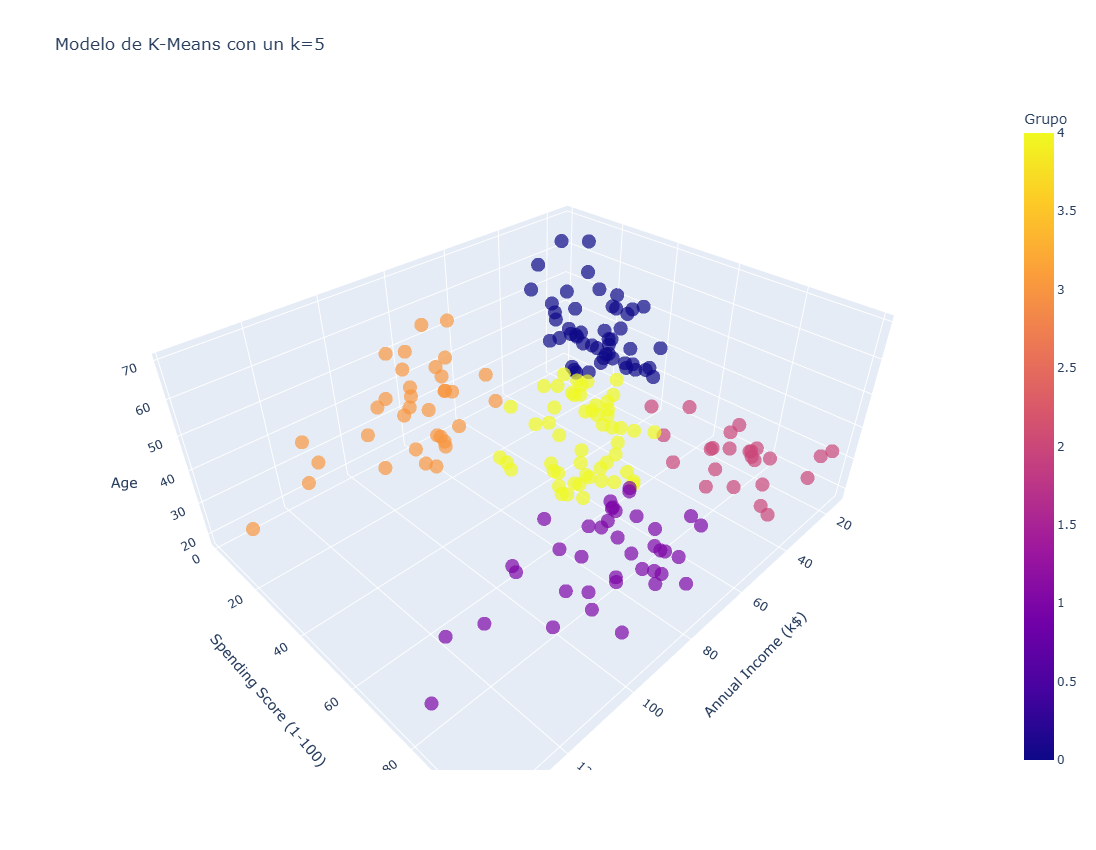

In [77]:
# Crear un modelo 3D de los datos agrupados

Grafica_3D = px.scatter_3d(df, x='Annual Income (k$)', y='Spending Score (1-100)', z='Age', color='Grupo', symbol='Grupo', symbol_map={0: 'circle', 1: 'circle', 2: 'circle', 3: 'circle', 4: 'circle', 5: 'circle'}, opacity=0.7, width=900, height=850, title=f'Modelo de K-Means con un k={5}', labels={'label': 'Cluster'}, color_discrete_map={})
Grafica_3D.update_layout(showlegend=False) 


In [ ]:
#hierarchical clustering

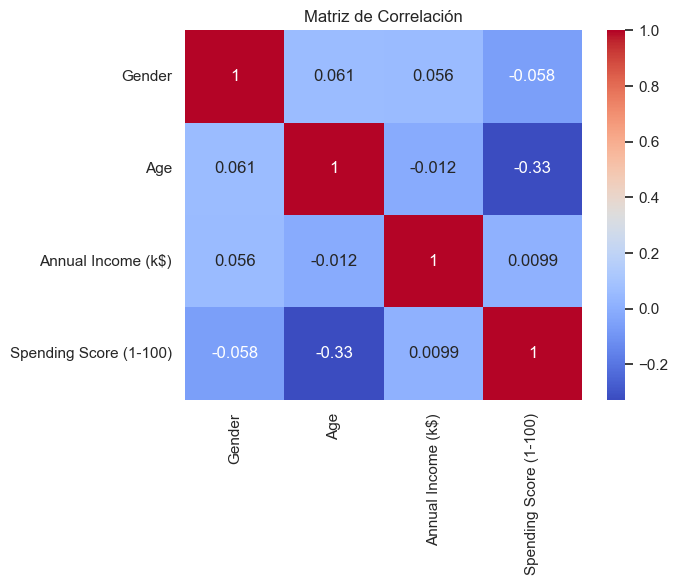

In [103]:

# Correlación
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()


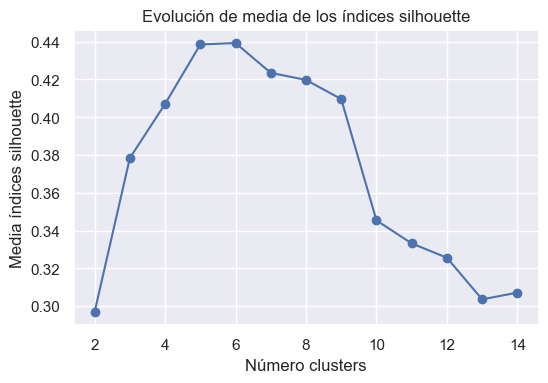

In [137]:
# Método silhouette para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(2, 15)
valores_medios_silhouette = []
for n_clusters in range_n_clusters:
    modelo = AgglomerativeClustering(
                    metric   = 'euclidean',
                    linkage    = 'ward',
                    n_clusters = n_clusters
             )
    cluster_labels = modelo.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    valores_medios_silhouette.append(silhouette_avg)
fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, valores_medios_silhouette, marker='o')
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');

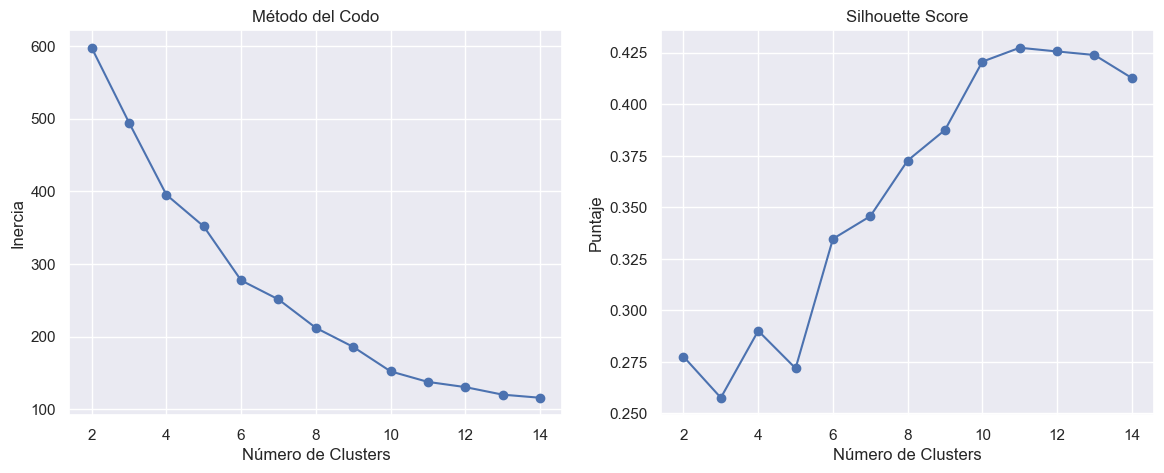

In [115]:
inertia = []
silhouette = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(scaled_data, kmeans.labels_))

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(k_range, inertia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')

plt.subplot(1,2,2)
plt.plot(k_range, silhouette, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Número de Clusters')
plt.ylabel('Puntaje')
plt.show()

best_k = k_range[np.argmax(silhouette)]

In [123]:
kmeans_final = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = kmeans_final.fit_predict(scaled_data)

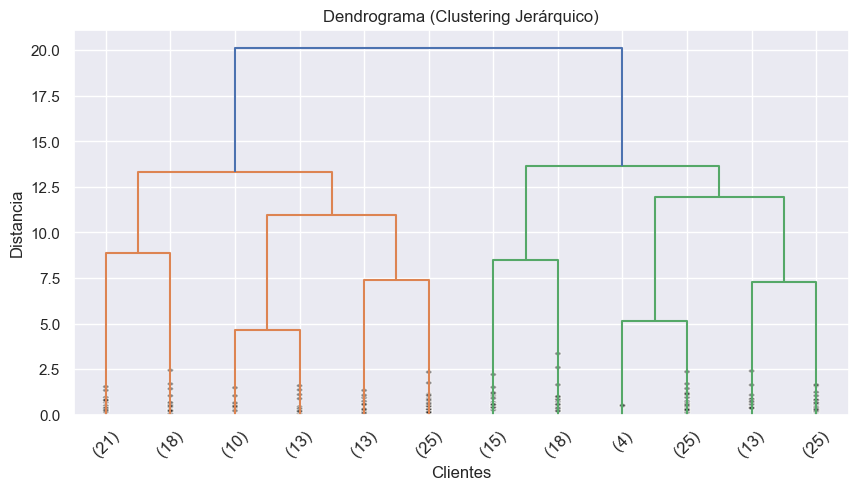

In [125]:
linked = linkage(scaled_data, method='ward')
hc_model = AgglomerativeClustering(n_clusters=best_k)
df['Hierarchical_Cluster'] = hc_model.fit_predict(scaled_data)

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=12, leaf_rotation=45., leaf_font_size=12., show_contracted=True)
plt.title('Dendrograma (Clustering Jerárquico)')
plt.xlabel('Clientes')
plt.ylabel('Distancia')
plt.show()

In [127]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Hierarchical_Cluster
0,1,19,15,39,2,0
1,1,21,15,81,2,0
2,0,20,16,6,4,9
3,0,23,16,77,4,8
4,0,31,17,40,4,9


In [129]:
observaciones = len(df)
X = df.drop('Gender', axis=1)
clusters = df['Gender']

sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)
davies_score = davies_bouldin_score(X, clusters)

table_data = [
    ["Numero de observaciones", observaciones],
    ["Coeficiente silhoutte", sil_score],
    ["Indice Calinski harabasz", calinski_score],
    ["Indice Davies bouldin", davies_score],
]

from tabulate import tabulate
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='prety'))
    

Metric                           Value
------------------------  ------------
Numero de observaciones   200
Coeficiente silhoutte       0.00949645
Indice Calinski harabasz    1.08272
Indice Davies bouldin      12.2634


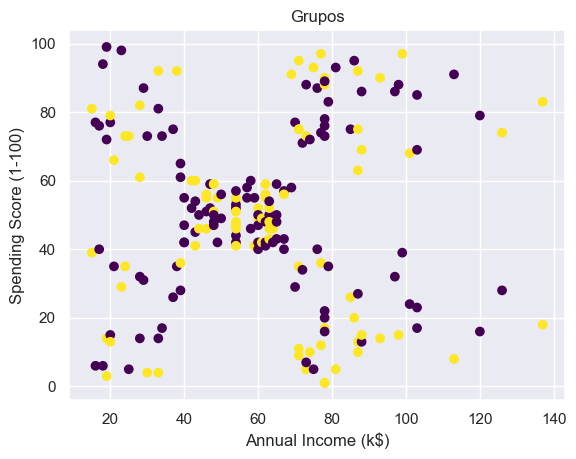

In [133]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Gender'], cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Grupos')
plt.show()

In [131]:
#7. Interpretar, analizar y documentar los resultados obtenidos

Del desempeño del modelo de KMEANS se puede describir:

. Coeficiente de Silhouette: La puntuación de Silhouette es de aproximadamente 0,38, aunque no se acerca a 1, todavía indica una buena cantidad de    separación entre los grupos. Sugiere que los grupos son algo distintos, pero puede haber ligeras superposiciones entre ellos. En general, una puntuación más cercana a 1 sería ideal

Índice de Calinski-Harabasz: La puntuación de Calinski Harabasz es de 133.49, que es aceptablemente alta, lo que indica que los clústeres están bien definidos. Una puntuación más alta en esta métrica generalmente indica mejores definiciones de clúster, lo que implica que nuestra agrupación en clústeres ha logrado encontrar una estructura sustancial en los datos.

Indice Davies Bouldin: La puntuación de Davies Bouldin de 0,984 es una puntuación razonable, lo que indica un nivel moderado de similitud entre cada grupo y el más similar. Una puntuación más baja es generalmente mejor, ya que indica menos similitud entre los clústeres y, por lo tanto, nuestra puntuación aquí sugiere una separación decente entre los grupos